In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
clean_data_path = "../data/data_clean.csv"
data_df = pd.read_csv(clean_data_path)

In [3]:
data_df.dtypes


gen                   float64
english_name           object
percent_male          float64
percent_female        float64
height_m              float64
weight_kg             float64
capture_rate          float64
base_egg_steps        float64
hp                    float64
attack                float64
defense               float64
sp_attack             float64
sp_defense            float64
speed                 float64
against_normal        float64
against_fire          float64
against_water         float64
against_electric      float64
against_grass         float64
against_ice           float64
against_fighting      float64
against_poison        float64
against_ground        float64
against_flying        float64
against_psychict      float64
against_bug           float64
against_rock          float64
against_ghost         float64
against_dragon        float64
against_dark          float64
against_steel         float64
against_fairy         float64
votes_first           float64
votes_top_

In [4]:
data_df.describe(include="all")

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
count,1024.000000,1024,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.0000,1024.000000,1024.000000,...,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
unique,NaN,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Bulbasaur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.738281,NaN,46.532100,38.233525,1.211035,66.953906,94.976562,7097.5000,70.152344,77.514648,...,1.092773,2.802734,15.544922,2.372070,3.283203,0.044922,0.030273,0.147461,6.318359,4.623047
std,2.632948,NaN,27.153005,24.713124,1.248642,121.331744,76.129587,6810.6675,26.624286,29.815854,...,0.545856,5.924761,27.267545,0.740691,1.584341,0.207234,0.171422,0.533101,4.949621,5.096766
min,1.000000,NaN,0.000000,0.000000,0.100000,0.100000,3.000000,640.0000,1.000000,5.000000,...,0.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,NaN,50.000000,11.860000,0.500000,8.500000,45.000000,3840.0000,50.000000,55.000000,...,1.000000,0.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,5.000000,NaN,50.200000,49.800000,1.000000,28.000000,60.000000,5120.0000,68.000000,75.000000,...,1.000000,1.000000,6.000000,3.000000,3.000000,0.000000,0.000000,0.000000,5.000000,1.000000
75%,7.000000,NaN,50.200000,50.000000,1.500000,70.000000,140.000000,6400.0000,85.000000,100.000000,...,1.000000,3.000000,15.000000,3.000000,5.000000,0.000000,0.000000,0.000000,10.000000,8.000000


In [5]:
n_primary_classes = data_df["class_primary"].nunique()
n_primary_classes

18

In [6]:
n_secondary_classes = data_df["class_secondary"].nunique()
n_secondary_classes

19


## Univariate z-score anomalies ##

What do these outliers look like?
Why are they different from the rest of the data?


Disregard generations for now. Take only numerical features

In [7]:
# Identify outliers;
# ignore "gen" columns and categorical columns
feature_cols = [col for col in data_df.columns if col not in ["english_name"]]

# let's use z-score method to identify outliers
from scipy import stats
z_scores = np.abs(stats.zscore(data_df[feature_cols], nan_policy="omit"))

z_scores_df = pd.DataFrame(z_scores, columns=feature_cols, index=data_df.index)

outlier_zscore_threshold = 3.0
outliers = (z_scores > outlier_zscore_threshold).any(axis=1)

data_df["outliers_zscore"] = outliers

# sort data by number of outlier features
data_df['num_outlier_features'] = (z_scores > outlier_zscore_threshold).sum(axis=1)
data_df_sorted = data_df.sort_values(by='num_outlier_features', ascending=False)


# List those detected features
data_df["outlier_feature_list"] = (z_scores_df > outlier_zscore_threshold).apply(
    lambda row: list(row.index[row]), axis=1
)


# Count how many outliers were found
num_outliers = outliers.sum()
print(f"Number of outlier samples identified: {num_outliers}")

Number of outlier samples identified: 381


In [8]:
#


data_df[["english_name", "outlier_feature_list"]]

,english_name,outlier_feature_list
0,Bulbasaur,"[votes_first, votes_top_6]"
1,Ivysaur,[]
2,Venusaur,"[has_mega_evolution, has_gigantamax]"
3,Charmander,[]
4,Charmeleon,[]
...,...,...
1019,Raging Bolt,"[height_m, weight_kg]"
1020,Iron Boulder,[]
1021,Iron Crown,[]
1022,Terapagos,[]


In [9]:
data_df_sorted.head(20)

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,outliers_zscore,num_outlier_features
804,7.0,Stakataka,0.00,0.00,5.5,820.0,30.0,30720.0,61.0,131.0,...,8.0,1.0,1.0,0.0,0.0,1.0,11,11,True,6
383,3.0,Rayquaza,0.00,0.00,7.0,206.5,45.0,30720.0,105.0,150.0,...,156.0,1.0,1.0,1.0,0.0,2.0,14,2,True,6
142,1.0,Snorlax,88.14,11.86,2.1,460.0,25.0,10240.0,160.0,110.0,...,98.0,3.0,3.0,0.0,1.0,0.0,4,1,True,5
798,7.0,Guzzlord,0.00,0.00,5.5,888.0,45.0,30720.0,223.0,101.0,...,5.0,1.0,1.0,0.0,0.0,1.0,15,15,True,5
719,6.0,Hoopa,0.00,0.00,0.5,9.0,3.0,30720.0,80.0,110.0,...,10.0,1.0,1.0,0.0,0.0,3.0,10,16,True,5
93,1.0,Gengar,50.20,49.80,1.5,40.5,45.0,5120.0,60.0,65.0,...,216.0,1.0,5.0,1.0,1.0,0.0,12,0,True,5
486,4.0,Giratina,0.00,0.00,4.5,750.0,3.0,30720.0,150.0,100.0,...,78.0,3.0,1.0,0.0,0.0,2.0,12,15,True,5
791,7.0,Lunala,0.00,0.00,4.0,120.0,45.0,30720.0,137.0,113.0,...,24.0,1.0,7.0,0.0,0.0,2.0,10,16,True,5
5,1.0,Charizard,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,84.0,...,248.0,2.0,5.0,1.0,1.0,0.0,1,2,True,5
247,2.0,Tyranitar,50.20,49.80,2.0,202.0,45.0,10240.0,100.0,134.0,...,136.0,2.0,5.0,1.0,0.0,0.0,11,3,True,4


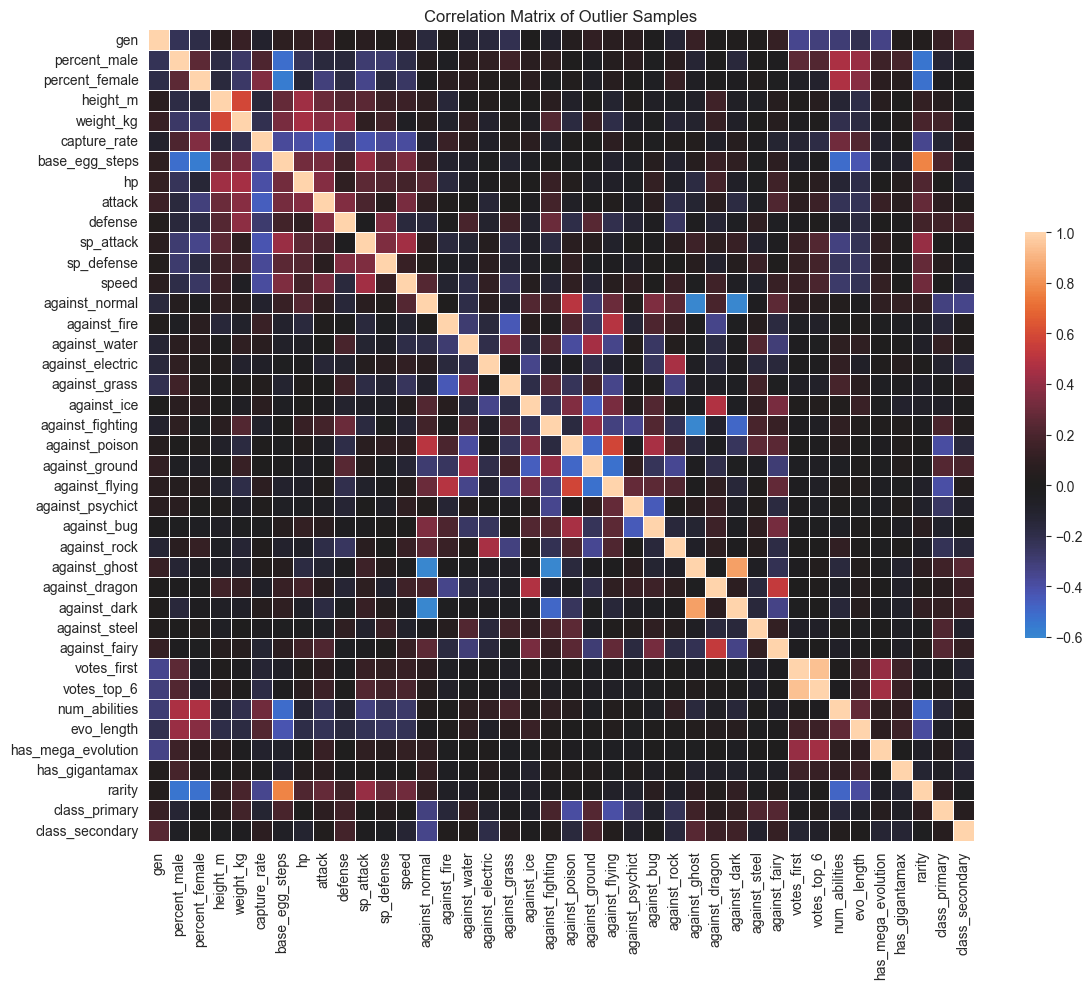

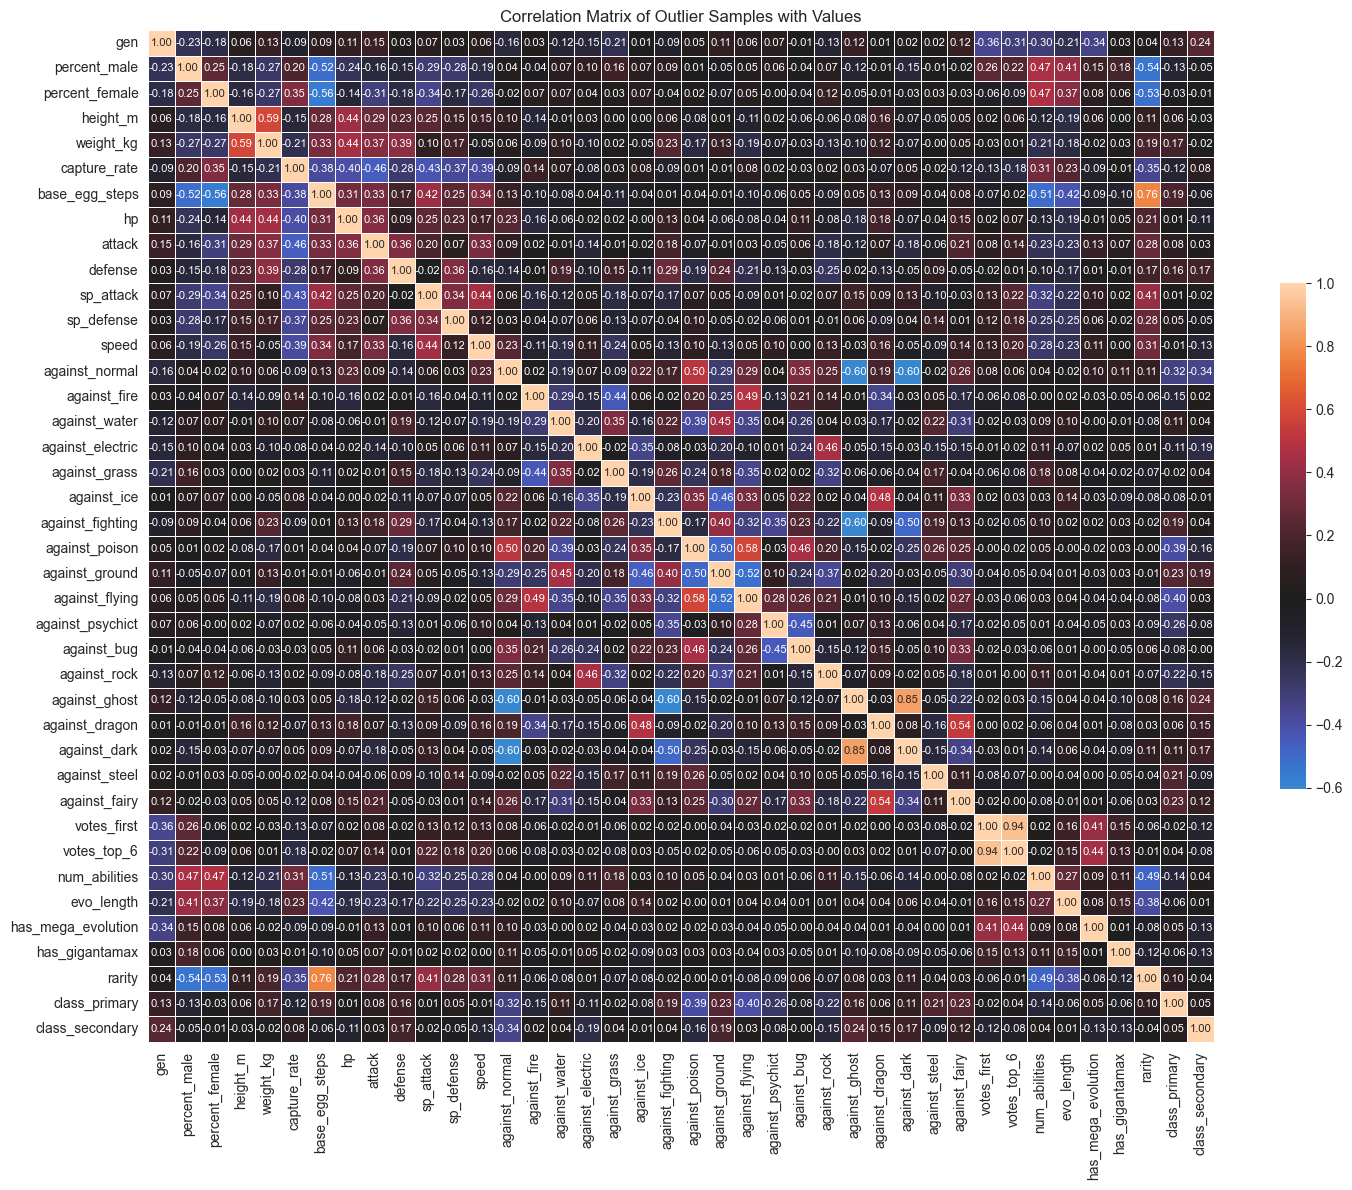

In [10]:
# Correlation heatmap of features for outlier samples
outlier_data = data_df[outliers]
outlier_features = outlier_data[feature_cols]
corr_matrix = outlier_features.corr()
plt.figure(figsize=(12, 10))
sns.color_palette("rocket")
sns.heatmap(corr_matrix, center=0, annot=False, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5})
plt.title("Correlation Matrix of Outlier Samples")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Let's add the actual values into the heatmap
# Make sure to make the figure larger for better readability
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5}, annot_kws={"size": 8})
plt.title("Correlation Matrix of Outlier Samples with Values")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
# Let's enumerate the most interesting correlations among outlier features
abs_corr = corr_matrix.abs()
pairs = (
    abs_corr.unstack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
)
pairs = pairs[pairs['var1'] != pairs['var2']]
# keep unique pairs (unordered) and sort by absolute correlation
pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted((r['var1'], r['var2']))), axis=1)
top_pairs = pairs.drop_duplicates(subset='pair_key').sort_values('abs_corr', ascending=False)

In [12]:
top_pairs.head(20)

,var1,var2,abs_corr,pair_key
1272,votes_first,votes_top_6,0.939382,"(votes_first, votes_top_6)"
1068,against_ghost,against_dark,0.849564,"(against_dark, against_ghost)"
277,base_egg_steps,rarity,0.761986,"(base_egg_steps, rarity)"
546,against_normal,against_ghost,0.604078,"(against_ghost, against_normal)"
786,against_fighting,against_ghost,0.598342,"(against_fighting, against_ghost)"
548,against_normal,against_dark,0.598283,"(against_dark, against_normal)"
124,height_m,weight_kg,0.587023,"(height_m, weight_kg)"
822,against_poison,against_flying,0.575488,"(against_flying, against_poison)"
86,percent_female,base_egg_steps,0.563860,"(base_egg_steps, percent_female)"
77,percent_male,rarity,0.539499,"(percent_male, rarity)"


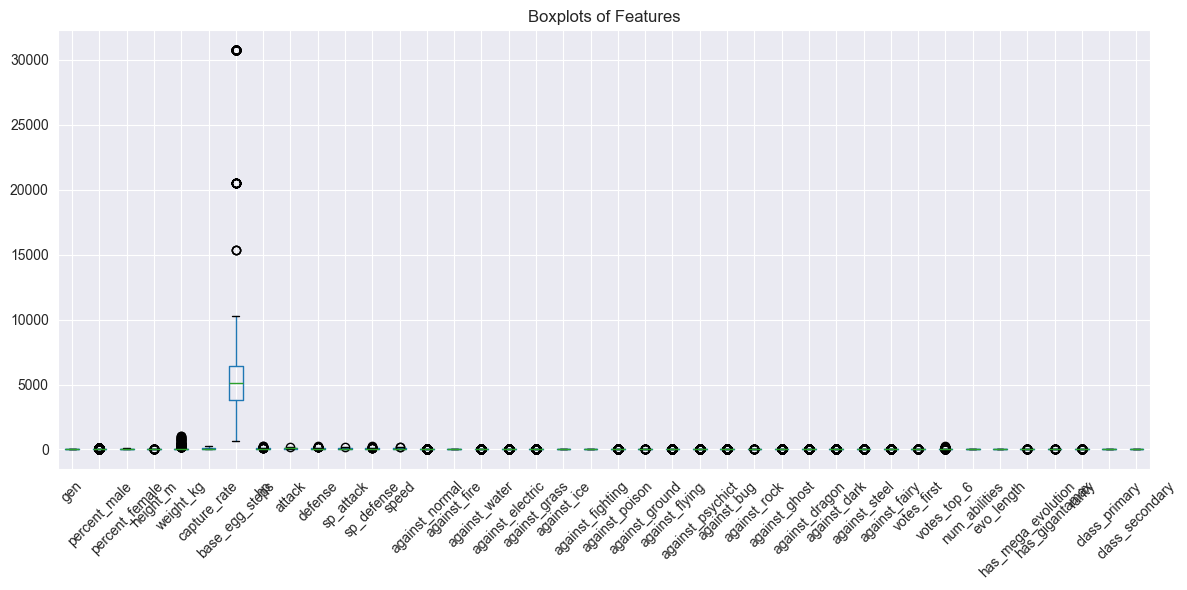

In [13]:
# Boxplots and histograms


plt.figure(figsize=(12, 6))
data_df[feature_cols].boxplot()
plt.title("Boxplots of Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Histograms of features

# fig, axes = plt.subplots(nrows=len(feature_cols), ncols=1, figsize=(10, 5 * len(feature_cols)))
# for ax, col in zip(axes, feature_cols):
#     sns.histplot(data_df[col], bins=30, kde=True, ax=ax)
#     ax.set_title(f"Histogram of {col}")
# plt.tight_layout()
# plt.show()

In [15]:
# Highlight pokemns with many outlier features in these distributions

threshold = data_df['num_outlier_features'].quantile(0.95)  # top 5% as high outlier count
high_outlier_data = data_df[data_df['num_outlier_features'] >= threshold].sort_values(by='num_outlier_features', ascending=False)

print("Pokemons with high number of outlier features:")
print(f"(Threshold: {threshold} outlier features)")
display(high_outlier_data[['english_name', 'num_outlier_features'] + feature_cols].reset_index(drop=True))

Pokemons with high number of outlier features:
(Threshold: 2.0 outlier features)


,english_name,num_outlier_features,gen,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,...,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
0,Rayquaza,6,3.0,0.00,0.00,7.0,206.5,45.0,30720.0,105.0,...,2.0,20.0,156.0,1.0,1.0,1.0,0.0,2.0,14,2
1,Stakataka,6,7.0,0.00,0.00,5.5,820.0,30.0,30720.0,61.0,...,0.5,0.0,8.0,1.0,1.0,0.0,0.0,1.0,11,11
2,Lunala,5,7.0,0.00,0.00,4.0,120.0,45.0,30720.0,137.0,...,1.0,2.0,24.0,1.0,7.0,0.0,0.0,2.0,10,16
3,Charizard,5,1.0,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,...,0.5,69.0,248.0,2.0,5.0,1.0,1.0,0.0,1,2
4,Guzzlord,5,7.0,0.00,0.00,5.5,888.0,45.0,30720.0,223.0,...,4.0,0.0,5.0,1.0,1.0,0.0,0.0,1.0,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,Jirachi,2,3.0,0.00,0.00,0.3,1.1,3.0,30720.0,100.0,...,0.5,7.0,46.0,1.0,1.0,0.0,0.0,3.0,16,10
137,Kyogre,2,3.0,0.00,0.00,4.5,352.0,3.0,30720.0,100.0,...,1.0,5.0,39.0,1.0,1.0,0.0,0.0,2.0,2,1
138,Latios,2,3.0,100.00,0.00,2.0,60.0,3.0,30720.0,80.0,...,2.0,4.0,29.0,1.0,1.0,1.0,0.0,1.0,14,10
139,Latias,2,3.0,0.00,100.00,1.4,40.0,3.0,30720.0,80.0,...,2.0,5.0,34.0,1.0,1.0,1.0,0.0,1.0,14,10


In [16]:
# Lets print count plot of top 20 pokemons with highest outlier features by their primary class

# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='class_primary', order=high_outlier_data['class_primary'].value_counts().index)
#
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Primary Class")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
#
# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='gen', order=high_outlier_data['gen'].value_counts().index)
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Generation")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



In [17]:
def scatter_with_outliers(df, x_col, y_col, outlier_mask, annotate=True):
    plt.figure(figsize=(10, 6))
    plt.scatter(df[~outlier_mask][x_col], df[~outlier_mask][y_col], label='Normal Data', alpha=0.4)
    plt.scatter(df[outlier_mask][x_col], df[outlier_mask][y_col], color='red', label='Outliers', alpha=0.7)

    # Annotate outlier points
    if annotate:
        for _, row in df[outlier_mask].iterrows():
            plt.annotate(row['english_name'], (row[x_col], row[y_col]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Scatter Plot of {y_col} vs {x_col} with Outliers Highlighted')
    plt.legend()
    plt.grid(True)
    plt.show()

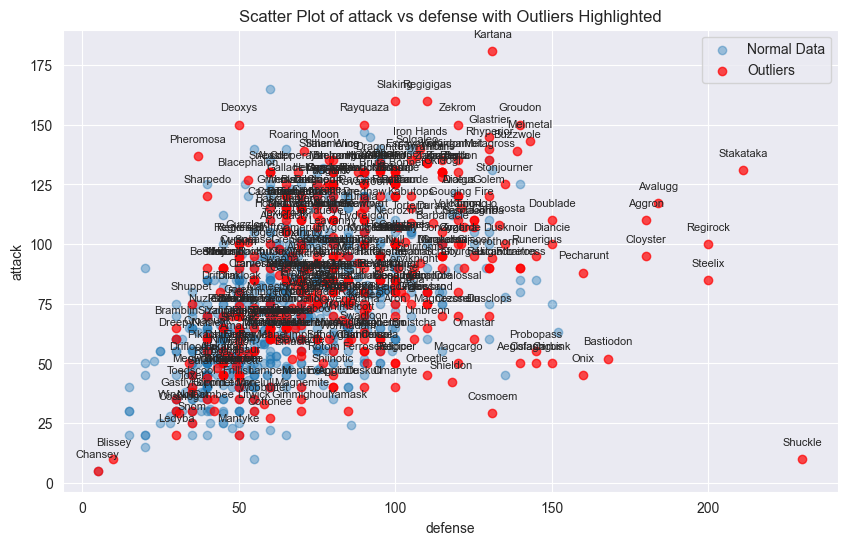

In [18]:
scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=True)
#scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=False)

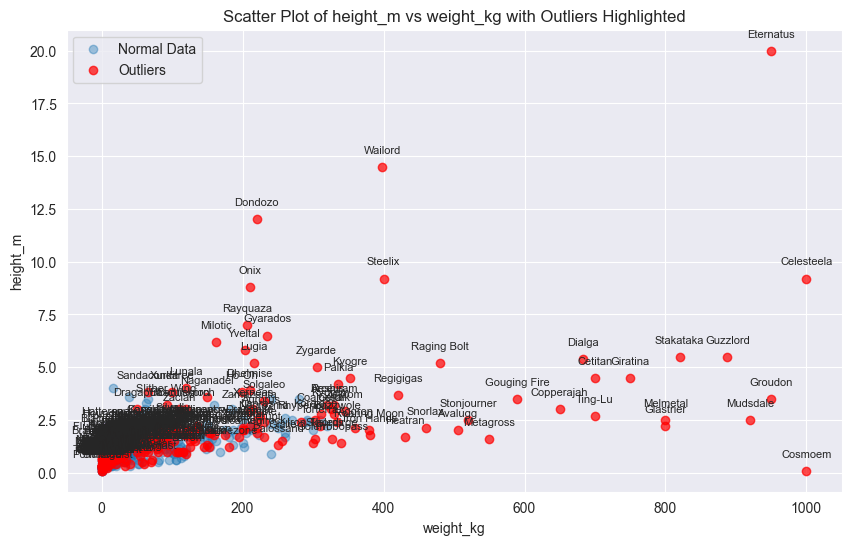

In [19]:
scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=True)
#scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=False)

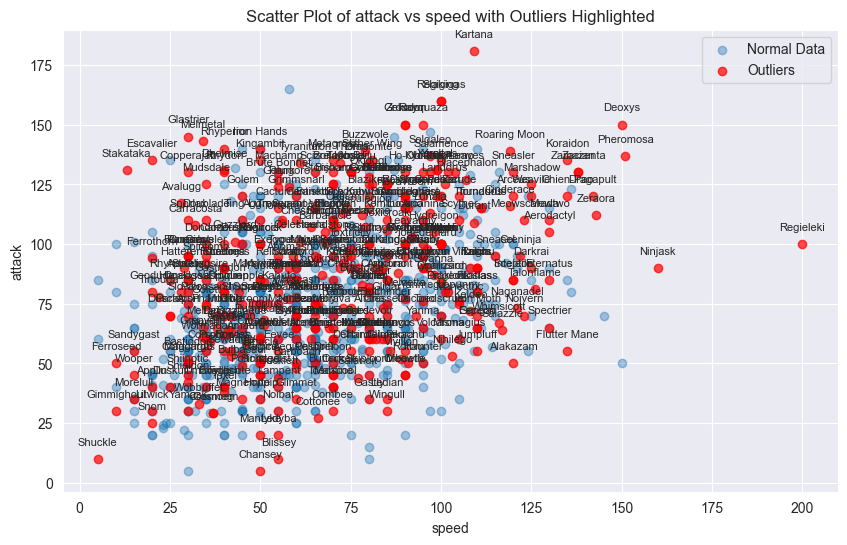

In [20]:
scatter_with_outliers(data_df, 'speed', 'attack', outliers, annotate=True)

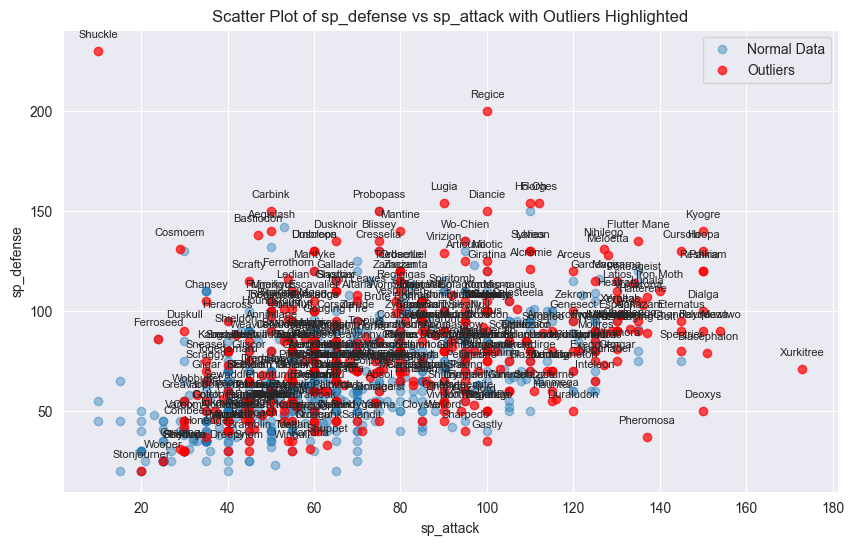

In [21]:
scatter_with_outliers(data_df, 'sp_attack', 'sp_defense', outliers, annotate=True)

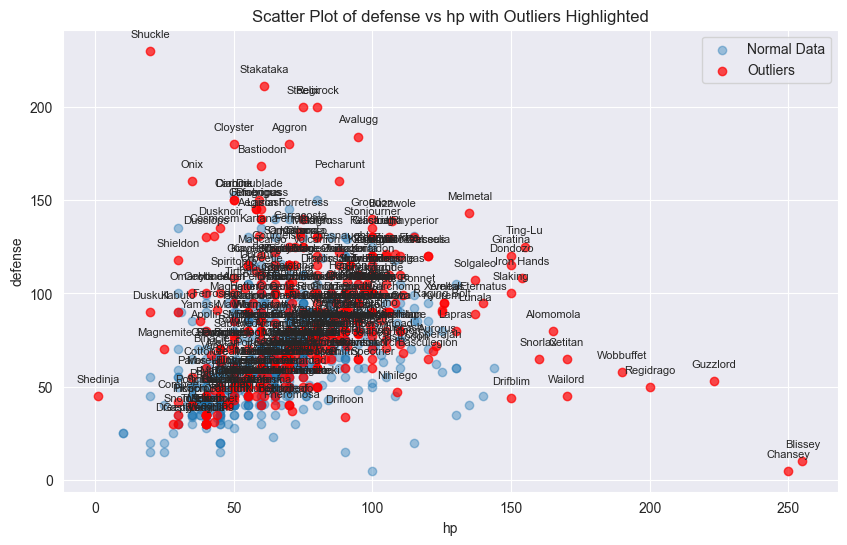

In [22]:
scatter_with_outliers(data_df, 'hp', 'defense', outliers, annotate=True)

In [23]:
# display scatter plots with top correlated feature pairs among outliers

# for _, row in top_pairs.head(10).iterrows():
#     scatter_with_outliers(data_df, row['var1'], row['var2'], outliers, annotate=True)

## Multivariate anomalies ##


In [24]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [25]:
num_cols = [c for c in data_df.select_dtypes(include=[np.number]).columns if c in feature_cols]
X = data_df[num_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
def visualize_score_distribution(score_column, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True)
    plt.title(title)
    plt.xlabel("Score")
    plt.grid(True)
    plt.show()

def plot_decision_function_2d(score_column, title, anomaly_flag_col=None, annotate=True):
    plt.figure(figsize=(9, 7))

    # Sort: anomalies on top
    df_sorted = data_df.sort_values(score_column)

    scatter = plt.scatter(
        df_sorted["pca_vis_1"],
        df_sorted["pca_vis_2"],
        c=df_sorted[score_column],
        cmap="viridis",
        alpha=0.7
    )

    plt.colorbar(scatter, label=score_column)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)

    if anomaly_flag_col is not None:
        anomalies = data_df[data_df[anomaly_flag_col]]

        # Highlight anomalies
        plt.scatter(
            anomalies["pca_vis_1"],
            anomalies["pca_vis_2"],
            color="red",
            s=60,
            edgecolor="black",
            label="Detected Anomaly"
        )

        # Add annotations
        if annotate:
            for _, row in anomalies.iterrows():
                plt.annotate(
                    row["english_name"],
                    (row["pca_vis_1"], row["pca_vis_2"]),
                    fontsize=6,
                    xytext=(3, 3),
                    textcoords="offset points"
                )

        plt.legend()
    plt.show()

def plot_score_with_anomalies(score_column, anomaly_flag_col, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True, color="gray")

    # overlay anomalies
    anomaly_scores = data_df.loc[data_df[anomaly_flag_col], score_column]
    plt.scatter(anomaly_scores, np.zeros_like(anomaly_scores),
                color="red", label="Anomalies", s=40)

    plt.title(title)
    plt.legend()
    plt.show()



### Isolation Forest ###

In [27]:
 # anomaly detection with isolation forest
from sklearn.ensemble import IsolationForest

In [28]:
# contamination estimate based on z-values (341 out of 1024 = 33%)
contamination_estimate = 0.33

In [29]:
# add a column to the original dataframe to keep track of anomalies detected by isolation forests

iso = IsolationForest(n_estimators=300,
                      contamination=contamination_estimate,
                      random_state=42)

iso_pred = iso.fit_predict(X_scaled)
iso_score = iso.decision_function(X_scaled)

data_df["anomaly_if"] = (iso_pred == -1)
data_df["iforest_score"] = iso_score


In [30]:
# Let's see the results

outliers_if_df = data_df[data_df["anomaly_if"] == True]

outliers_if_df

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,outliers_zscore,num_outlier_features,outlier_feature_list,anomaly_if,iforest_score
0,1.0,Bulbasaur,88.14,11.86,0.7,6.9,45.0,5120.0,45.0,49.0,...,0.0,0.0,0.0,0,0,True,2,"[votes_first, votes_top_6]",True,-0.012648
2,1.0,Venusaur,88.14,11.86,2.0,100.0,45.0,5120.0,80.0,82.0,...,1.0,1.0,0.0,0,0,True,2,"[has_mega_evolution, has_gigantamax]",True,-0.059974
5,1.0,Charizard,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,84.0,...,1.0,1.0,0.0,1,2,True,5,"[against_rock, votes_first, votes_top_6, has_m...",True,-0.109607
8,1.0,Blastoise,88.14,11.86,1.6,85.5,45.0,5120.0,79.0,83.0,...,1.0,1.0,0.0,2,1,True,2,"[has_mega_evolution, has_gigantamax]",True,-0.052584
11,1.0,Butterfree,50.20,49.80,1.1,32.0,45.0,3840.0,60.0,45.0,...,0.0,1.0,0.0,3,2,True,2,"[against_rock, has_gigantamax]",True,-0.018174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,9.0,Gouging Fire,0.00,0.00,3.5,590.0,10.0,6400.0,105.0,115.0,...,0.0,0.0,0.0,1,15,True,1,[weight_kg],True,-0.038879
1019,9.0,Raging Bolt,0.00,0.00,5.2,480.0,10.0,6400.0,125.0,73.0,...,0.0,0.0,0.0,6,15,True,2,"[height_m, weight_kg]",True,-0.048726
1020,9.0,Iron Boulder,0.00,0.00,1.5,162.5,10.0,6400.0,90.0,120.0,...,0.0,0.0,0.0,11,10,False,0,[],True,-0.046305
1021,9.0,Iron Crown,0.00,0.00,1.6,156.0,10.0,6400.0,90.0,72.0,...,0.0,0.0,0.0,16,10,False,0,[],True,-0.047608


In [31]:
len(outliers_if_df)

338

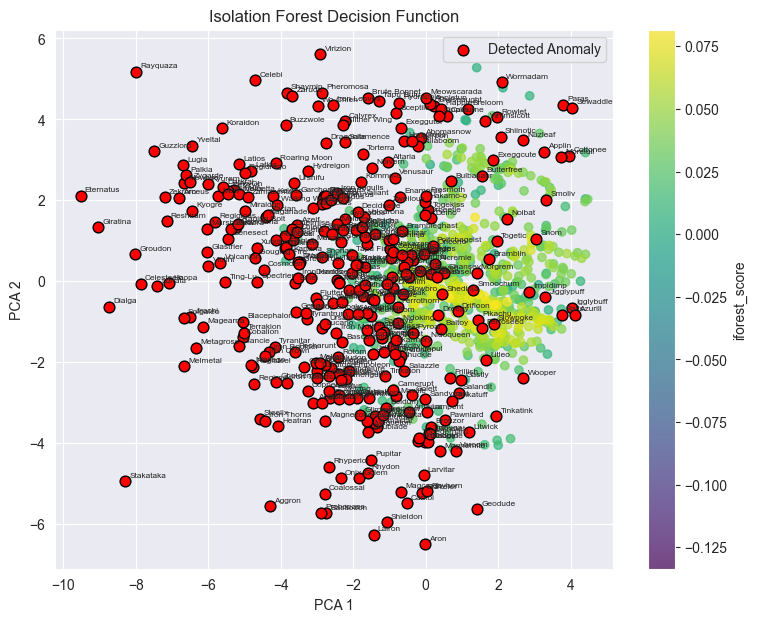

In [38]:
# visualize_score_distribution("iforest_score", "Isolation Forest Score Distribution")
# scatter_with_outliers(data_df, 'weight_kg', 'height_m', data_df["anomaly_if"], annotate=True)
# scatter_with_outliers(data_df, 'hp', 'defense', data_df["anomaly_if"], annotate=True)

plot_decision_function_2d(
    score_column="iforest_score",
    title="Isolation Forest Decision Function",
    anomaly_flag_col="anomaly_if",
    annotate=True
)


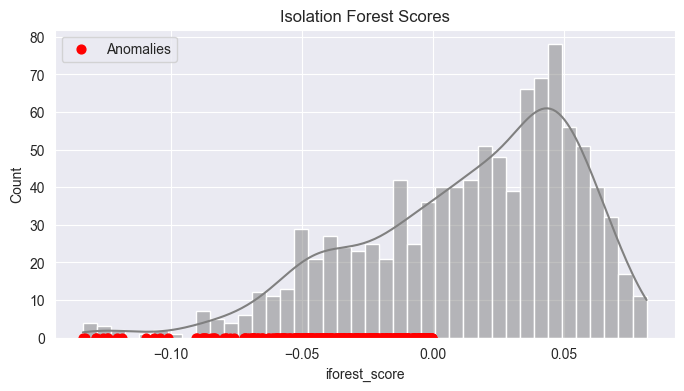

In [39]:
plot_score_with_anomalies("iforest_score", "anomaly_if", "Isolation Forest Scores")

## Local Outlier Factor ##

In [40]:
from sklearn.neighbors import LocalOutlierFactor

In [41]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_estimate,
    novelty=False
)

lof_pred = lof.fit_predict(X_scaled) # -1 = anomaly, 1 = normal
lof_score = lof.negative_outlier_factor_ # more negative = more abnormal

data_df["anomaly_lof"] = (lof_pred == -1)
data_df["lof_score"] = lof_score

In [42]:
len(data_df[data_df["anomaly_lof"] == True])

338

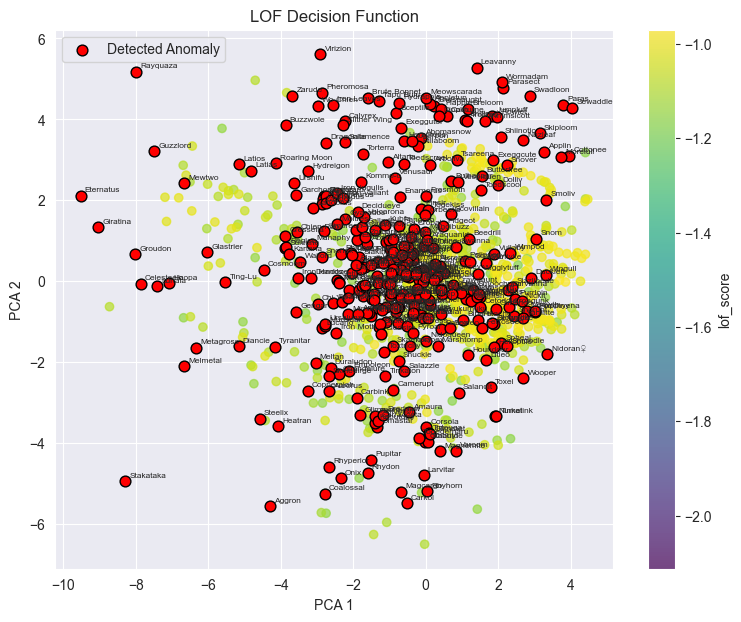

In [43]:

plot_decision_function_2d(
    score_column="lof_score",
    title="LOF Decision Function",
    anomaly_flag_col="anomaly_lof",
    annotate=True
)


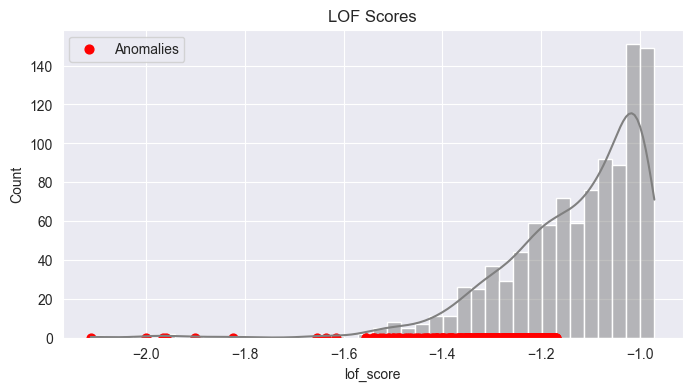

In [44]:
plot_score_with_anomalies("lof_score", "anomaly_lof", "LOF Scores")

## PCA anomaly score ##

In [45]:
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

pca_dist = np.linalg.norm(X_pca, axis=1)

pca_contamination = contamination_estimate
pca_threshold = np.quantile(pca_dist, 1 - pca_contamination)

data_df["pca_dist"] = pca_dist
data_df["anomaly_pca"] = pca_dist > pca_threshold

In [47]:
# len(data_df["anomaly_pca"] == True)
print(len(data_df[data_df["anomaly_pca"] == True]))
print(len(data_df[data_df["anomaly_pca"] == False]))


338
686


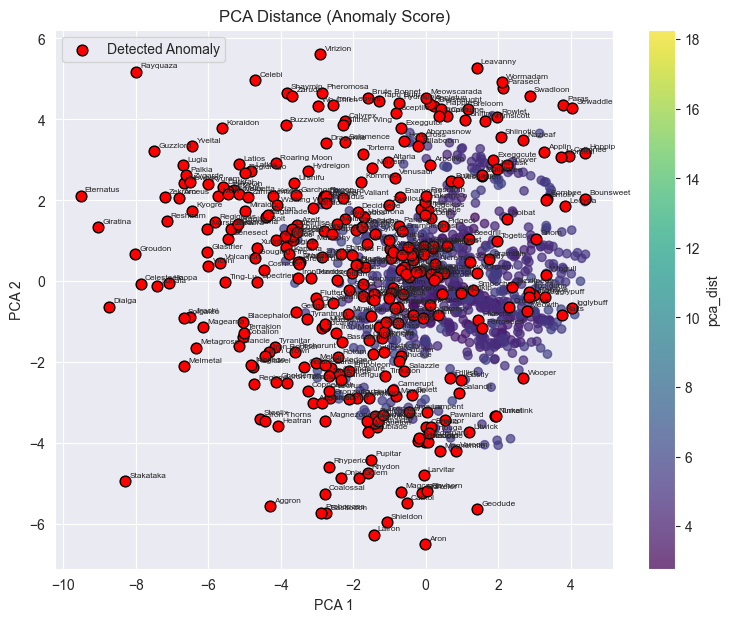

In [48]:
plot_decision_function_2d(
    score_column="pca_dist",
    title="PCA Distance (Anomaly Score)",
    anomaly_flag_col="anomaly_pca"
)


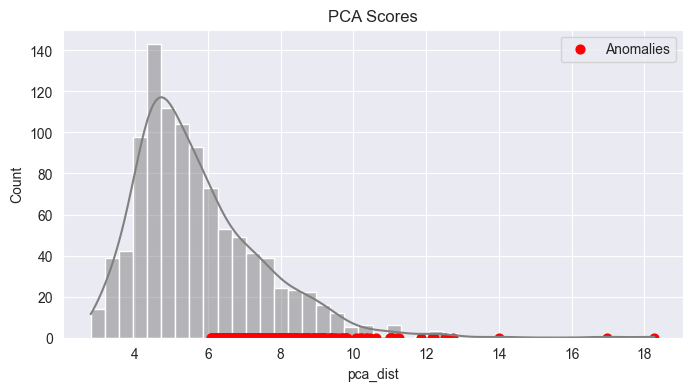

In [49]:
plot_score_with_anomalies("pca_dist", "anomaly_pca", "PCA Scores")

## One Class SVM ##

In [50]:
from sklearn.svm import OneClassSVM



In [51]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=contamination_estimate
)

ocsvm.fit(X_scaled)
ocsvm_pred = ocsvm.predict(X_scaled)         # -1 = anomaly, 1 = normal
ocsvm_score = ocsvm.decision_function(X_scaled)  # higher = more normal

data_df["anomaly_ocsvm"] = (ocsvm_pred == -1)
data_df["ocsvm_score"] = ocsvm_score


In [52]:
len(data_df["ocsvm_score"] == True)

1024

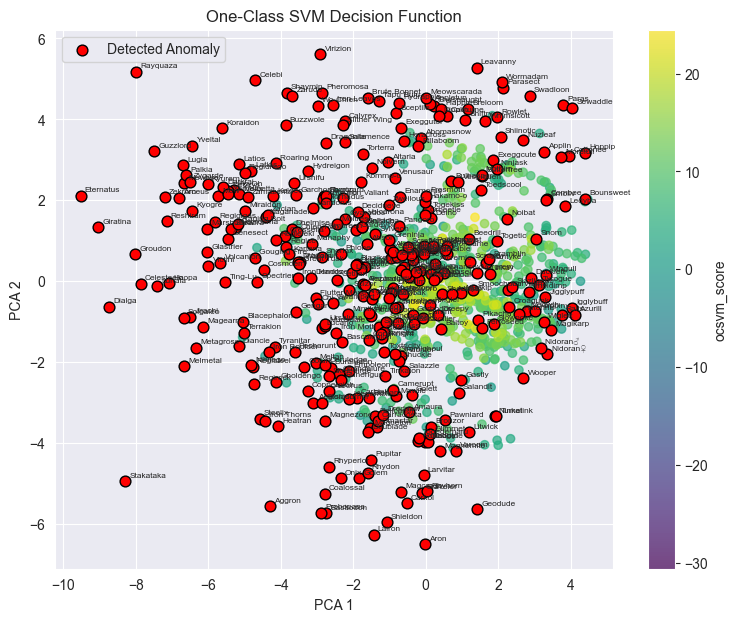

In [53]:
plot_decision_function_2d(
    score_column="ocsvm_score",
    title="One-Class SVM Decision Function",
    anomaly_flag_col="anomaly_ocsvm",
    annotate=True
)


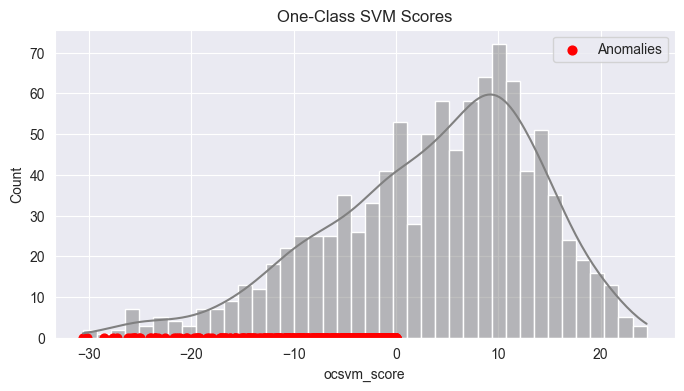

In [54]:
plot_score_with_anomalies("ocsvm_score", "anomaly_ocsvm", "One-Class SVM Scores")

## All classifiers in one ##


In [55]:
# Compute 2D PCA for visualization (independent of your PCA anomaly detector)
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

data_df["pca_vis_1"] = X_vis[:, 0]
data_df["pca_vis_2"] = X_vis[:, 1]


In [56]:
classif_cols = [
    "anomaly_if",
    "anomaly_lof",
    "anomaly_pca",
    "anomaly_ocsvm",
    # "outliers_zscore",
    # "anomaly_strong"
]

# save fired anomalies from each method
data_df["anomaly_fired"] = data_df[classif_cols].sum(axis=1)
data_df["anomaly_any"] = data_df[classif_cols].any(axis=1)

# classified as an anomaly by at least N methods
classif_threshold = 3

data_df["anomaly_strong"] = data_df["anomaly_fired"] > classif_threshold

In [57]:
len(data_df[data_df["anomaly_strong"] == True])

172

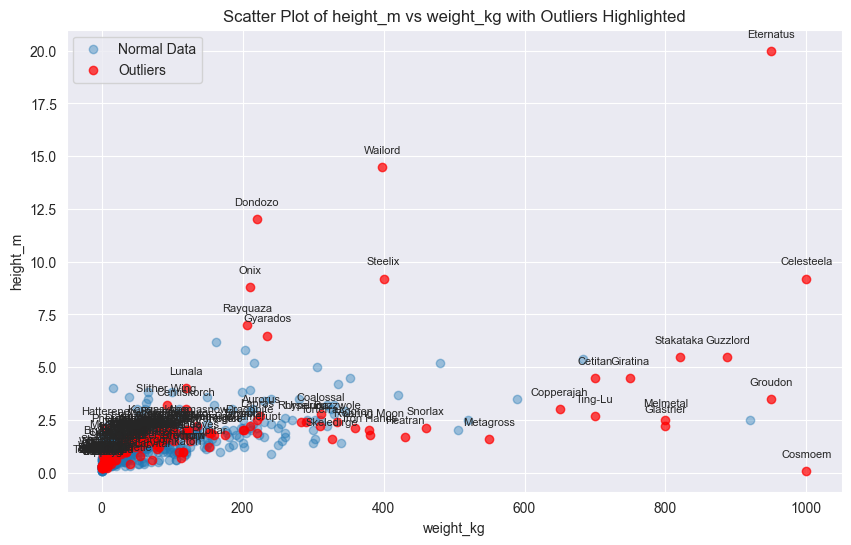

In [58]:
highlight_mask = data_df["anomaly_strong"]
scatter_with_outliers(data_df, 'weight_kg', 'height_m', highlight_mask, annotate=True)


# What features do outliers/anomalies differ in? #

## Which features show the strongest separation between anomaly and normal groups? ##

### U-test ###

For each feature, compare **mean, median, and variance**
Compute effect size - how big the difference is
"Effect" refers to how much an estimator or method is influenced by outliers or small deviations from ideal model assumptions

In [59]:
import scipy.stats as stats

def compare_features(anomaly_flag="anomaly_strong"):
    rows = []
    anomalies = data_df[data_df[anomaly_flag]]
    normals = data_df[~data_df[anomaly_flag]]

    for col in num_cols:
        a = anomalies[col]
        n = normals[col]

        # Effect size
        d = (a.mean() - n.mean()) / np.sqrt((a.var() + n.var())/2)

        # Statistical test
        u_stat, p_val = stats.mannwhitneyu(a, n, alternative="two-sided")

        rows.append({
            "feature": col,
            "mean_anomaly": a.mean(),
            "mean_normal": n.mean(),
            "effect_size": d,
            "p_value": p_val
        })

    return pd.DataFrame(rows).sort_values("effect_size", ascending=False)


In [60]:
comparison_df = compare_features()
display(comparison_df.head(15))

,feature,mean_anomaly,mean_normal,effect_size,p_value
32,votes_top_6,37.424419,11.127934,0.707990,2.013388e-12
31,votes_first,7.343023,1.886150,0.644888,6.536150e-10
39,class_secondary,7.331395,4.076291,0.643504,2.244733e-17
35,has_mega_evolution,0.203488,0.012911,0.642825,3.781752e-28
11,sp_defense,82.587209,67.712441,0.539017,1.054626e-10
4,weight_kg,140.302907,52.146362,0.533431,3.603176e-10
9,defense,85.918605,69.812207,0.521496,1.606360e-10
36,has_gigantamax,0.133721,0.009390,0.495683,4.096935e-18
10,sp_attack,82.476744,67.537559,0.493483,1.024886e-08
7,hp,82.581395,67.643192,0.491697,4.913944e-09


Outliers tend to have ....

### Isolation Forest ###
Using SHAP https://shap.readthedocs.io/en/latest/

shap values in the context of isolation forest score:


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


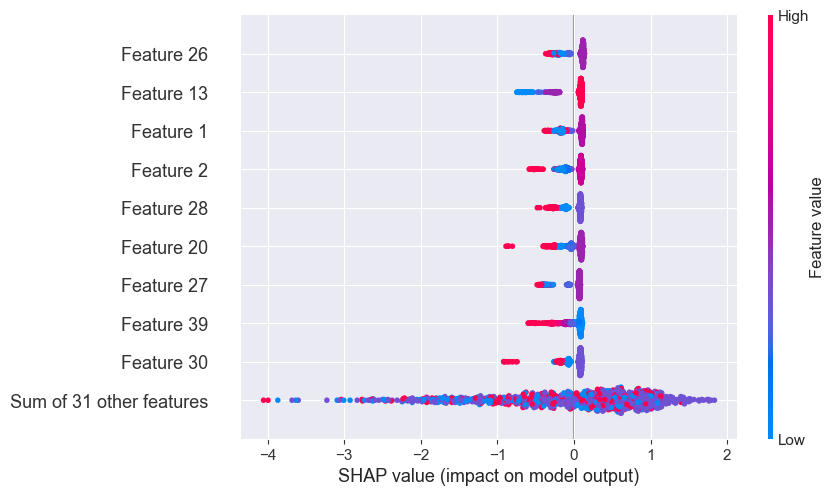

In [61]:
import shap
import tqdm as notebook_tqdm

explainer = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_scaled)

# shap.summary_plot(shap_values, X_scaled, feature_names=num_cols)
shap.plots.beeswarm(explainer(X_scaled))



### LOF ###


In [62]:
# lof.feature_importances_

### One-Class SVM ###


In [63]:
# ocsvm.feature_importances_

### PCA distances ###

Which original features have the largest loadings in PCs where anomalies are extreme?

In [64]:
loading_df = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))]
)

display(loading_df)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
gen,-0.076017,0.026506,0.014828,-0.267866,0.031067,0.100027,0.097680,0.099918,-0.123045,0.427015,...,0.251788,0.174285,-0.256310,-0.279704,-0.122253,0.018584,-0.181327,0.081937,0.245325,0.142151
percent_male,0.164688,-0.023722,-0.122109,0.259447,-0.086532,-0.022755,0.132194,-0.067820,-0.120387,0.213260,...,-0.018245,-0.213913,-0.070264,-0.032613,-0.002485,0.089040,0.280079,-0.010811,0.188117,0.155850
percent_female,0.208559,-0.045239,-0.027645,-0.028023,-0.111414,0.042932,-0.027520,0.346747,-0.072365,-0.171777,...,0.047270,0.035294,0.078067,0.040291,0.036881,-0.024807,-0.372852,0.097834,-0.075434,-0.140931
height_m,-0.236353,0.050411,-0.125214,0.035748,0.046956,0.042305,0.143696,0.171891,-0.142826,-0.321357,...,0.098514,0.022795,-0.272035,-0.203099,0.169734,-0.053530,0.253350,-0.227557,-0.201159,-0.070852
weight_kg,-0.256080,-0.021695,-0.144497,-0.063921,-0.004930,0.095715,0.097678,0.076798,-0.088143,-0.357047,...,0.128644,0.077245,-0.238741,-0.095085,0.063611,-0.022239,0.094209,-0.096683,-0.035426,-0.141773
capture_rate,0.285449,-0.092969,0.032792,-0.106095,-0.021466,-0.064841,0.007674,-0.052224,0.132002,-0.204425,...,0.078507,0.280632,-0.078948,-0.147141,-0.009427,0.019500,0.179529,-0.047611,0.029991,-0.033580
base_egg_steps,-0.280303,0.098562,0.061903,-0.100180,0.141295,-0.095400,-0.036684,-0.186650,0.251891,-0.189462,...,0.062914,0.052692,0.095774,0.142837,0.128016,-0.042820,0.064576,0.039907,0.145665,0.100034
hp,-0.239999,0.085155,-0.171544,0.010558,0.046526,0.050699,0.022112,0.147945,-0.217333,-0.177928,...,0.116175,-0.076192,-0.069523,-0.080200,0.045092,-0.184300,-0.166782,0.439663,0.192476,0.256464
attack,-0.254904,0.065033,-0.205582,0.035123,-0.000804,0.125592,0.126922,0.029302,-0.045843,0.097985,...,-0.073962,-0.239272,0.305800,-0.230940,0.126414,-0.081217,-0.176213,0.064608,0.147535,-0.107005
defense,-0.256460,-0.061154,-0.062159,-0.037479,-0.102526,0.211180,-0.019249,0.063042,-0.208225,-0.056460,...,-0.234721,-0.002243,0.140546,0.157405,-0.293132,0.146825,-0.102961,-0.242373,0.071649,-0.187971


In [65]:
loading_df["abs_PC1_loading"] = loading_df["PC1"].abs()
loading_df.sort_values("abs_PC1_loading", ascending=False).head(10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,abs_PC1_loading
capture_rate,0.285449,-0.092969,0.032792,-0.106095,-0.021466,-0.064841,0.007674,-0.052224,0.132002,-0.204425,...,0.280632,-0.078948,-0.147141,-0.009427,0.019500,0.179529,-0.047611,0.029991,-0.033580,0.285449
base_egg_steps,-0.280303,0.098562,0.061903,-0.100180,0.141295,-0.095400,-0.036684,-0.186650,0.251891,-0.189462,...,0.052692,0.095774,0.142837,0.128016,-0.042820,0.064576,0.039907,0.145665,0.100034,0.280303
defense,-0.256460,-0.061154,-0.062159,-0.037479,-0.102526,0.211180,-0.019249,0.063042,-0.208225,-0.056460,...,-0.002243,0.140546,0.157405,-0.293132,0.146825,-0.102961,-0.242373,0.071649,-0.187971,0.256460
weight_kg,-0.256080,-0.021695,-0.144497,-0.063921,-0.004930,0.095715,0.097678,0.076798,-0.088143,-0.357047,...,0.077245,-0.238741,-0.095085,0.063611,-0.022239,0.094209,-0.096683,-0.035426,-0.141773,0.256080
attack,-0.254904,0.065033,-0.205582,0.035123,-0.000804,0.125592,0.126922,0.029302,-0.045843,0.097985,...,-0.239272,0.305800,-0.230940,0.126414,-0.081217,-0.176213,0.064608,0.147535,-0.107005,0.254904
sp_attack,-0.250130,0.125951,0.116643,0.113208,0.084765,-0.054743,-0.089666,0.021636,-0.117172,0.120737,...,-0.069217,-0.116199,0.151843,0.147786,-0.003589,0.089959,-0.094858,-0.046435,0.133106,0.250130
sp_defense,-0.247336,0.085413,0.070641,0.051354,-0.014536,0.122905,-0.153735,0.117326,-0.182306,0.030467,...,-0.000290,-0.087394,0.363393,-0.314838,0.200849,0.044560,-0.041685,-0.041462,-0.021394,0.247336
rarity,-0.242615,0.097070,0.096288,-0.100561,0.173975,-0.077097,-0.126514,-0.224399,0.250862,-0.136061,...,0.125030,0.164977,0.178521,0.125525,-0.097196,-0.084316,0.032087,0.267071,0.118064,0.242615
hp,-0.239999,0.085155,-0.171544,0.010558,0.046526,0.050699,0.022112,0.147945,-0.217333,-0.177928,...,-0.076192,-0.069523,-0.080200,0.045092,-0.184300,-0.166782,0.439663,0.192476,0.256464,0.239999
height_m,-0.236353,0.050411,-0.125214,0.035748,0.046956,0.042305,0.143696,0.171891,-0.142826,-0.321357,...,0.022795,-0.272035,-0.203099,0.169734,-0.053530,0.253350,-0.227557,-0.201159,-0.070852,0.236353


### Z-scores ###


In [66]:
outliers_zscores_df = data_df[
    (data_df["outliers_zscore"]) &
    (data_df["outlier_feature_list"].str.len() >= 1)
][["english_name", "outlier_feature_list"]]


In [67]:
outliers_zscores_df


,english_name,outlier_feature_list
0,Bulbasaur,"[votes_first, votes_top_6]"
2,Venusaur,"[has_mega_evolution, has_gigantamax]"
5,Charizard,"[against_rock, votes_first, votes_top_6, has_m..."
8,Blastoise,"[has_mega_evolution, has_gigantamax]"
11,Butterfree,"[against_rock, has_gigantamax]"
...,...,...
1012,Okidogi,[against_psychict]
1017,Hydrapple,[against_ice]
1018,Gouging Fire,[weight_kg]
1019,Raging Bolt,"[height_m, weight_kg]"


In [68]:
len(outliers_zscores_df)


381

# Distribution of anomalies/outliers across generations #

In [69]:
anomaly_flag = "anomaly_strong"

gen_counts = data_df.groupby("gen")[anomaly_flag].sum()
gen_total = data_df.groupby("gen").size()

anomaly_rate = (gen_counts / gen_total).rename("anomaly_rate")

distribution_df = pd.concat(
    [
        gen_total.rename("total"),
        gen_counts.rename("anomalies"),
        anomaly_rate
    ],
    axis=1
)

In [70]:
distribution_df


,total,anomalies,anomaly_rate
gen,,,
1.0,151,33,0.218543
2.0,100,14,0.140000
3.0,135,24,0.177778
4.0,107,14,0.130841
5.0,156,12,0.076923
6.0,72,7,0.097222
7.0,88,22,0.250000
8.0,95,24,0.252632
9.0,120,22,0.183333


/var/folders/8y/0_xr6dfx6gq8z24st9njsbpm0000gn/T/ipykernel_41924/4090103192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_df.index, y=distribution_df["anomalies"], palette="viridis")


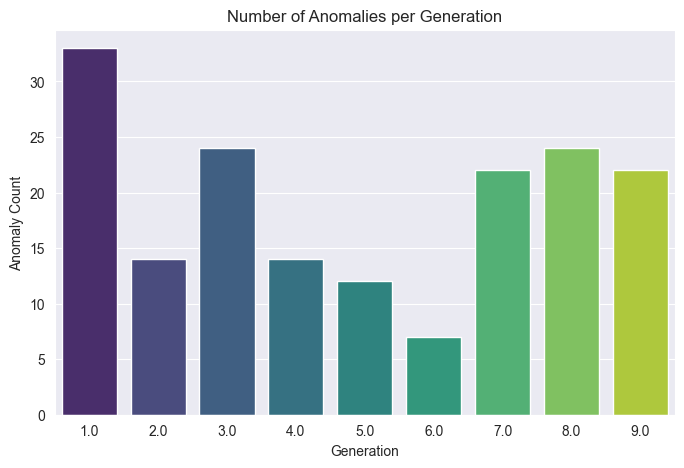

In [71]:
# Plot anomaly distribution by generation

plt.figure(figsize=(8,5))
sns.barplot(x=distribution_df.index, y=distribution_df["anomalies"], palette="viridis")
plt.title("Number of Anomalies per Generation")
plt.xlabel("Generation")
plt.ylabel("Anomaly Count")
plt.grid(True, axis='y')
plt.show()

/var/folders/8y/0_xr6dfx6gq8z24st9njsbpm0000gn/T/ipykernel_41924/2951354643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_df.index, y=distribution_df["anomaly_rate"], palette="coolwarm")


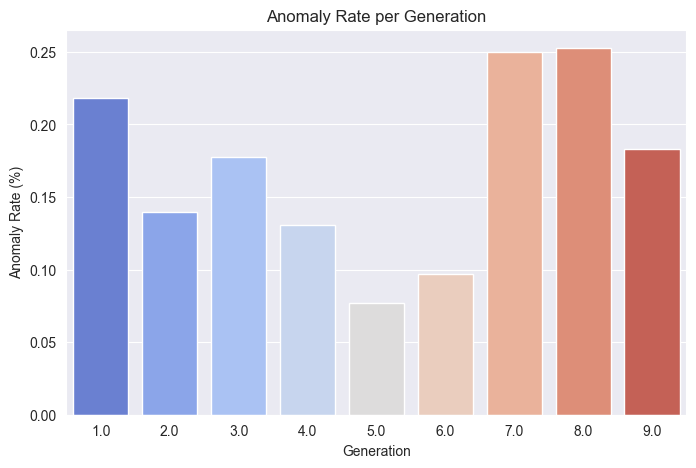

In [72]:
# plot of rates

plt.figure(figsize=(8,5))
sns.barplot(x=distribution_df.index, y=distribution_df["anomaly_rate"], palette="coolwarm")
plt.title("Anomaly Rate per Generation")
plt.xlabel("Generation")
plt.ylabel("Anomaly Rate (%)")
plt.grid(True, axis='y')
plt.show()


The generatoin with most outliers/anomalies is no. 8

Spearman rank correlation - check whether anomaly rate increases with generation number

Spearman's correlation determines the strength and direction of the monotonic relationship (A monotonic relationship is a relationship that does one of the following: (1) as the value of one variable increases, so does the value of the other variable; or (2) as the value of one variable increases, the other variable value decreases) between your two variables rather than the strength and direction of the linear relationship between your two variables, which is what Pearson's correlation determines. https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php

Assumptions:
* two variables that are either ordinal, interval, or ratio

In [73]:
from scipy.stats import spearmanr

In [74]:
corr, pval = spearmanr(distribution_df.index, distribution_df["anomaly_rate"])
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.4f}")


Spearman correlation: 0.267, p-value: 0.4879


Weak / no trend

Are anomaly rates significantly different across generations?

Chi-square test of indepence


In [75]:
# build contingency table
contingency = pd.DataFrame({
    "anomaly": gen_counts,
    "normal": gen_total - gen_counts
})

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square p-value: {p:.4f}")


Chi-square p-value: 0.0012


===> Generations have significant differences in anomaly frequency

Comparing detectors across generatoins to see
* which methods agree
* which generations appear more anomalous (consistently)
* whether a certain generation stands out

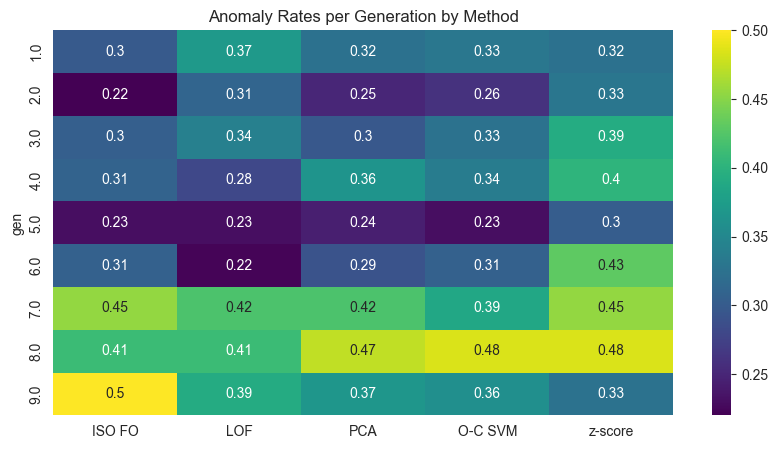

In [78]:
classif_cols = [
    "anomaly_if",
    "anomaly_lof",
    "anomaly_pca",
    "anomaly_ocsvm",
    "outliers_zscore",
    # "anomaly_strong"
]

col_labels = {
    "anomaly_if": "ISO FO",
    "anomaly_lof": "LOF",
    "anomaly_pca": "PCA",
    "anomaly_ocsvm": "O-C SVM",
    "outliers_zscore": "z-score"
}

heatmap_data = {
    col_labels[m]: data_df.groupby("gen")[m].mean()
    for m in classif_cols
}

heatmap_df = pd.DataFrame(heatmap_data)

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_df, annot=True, cmap="viridis")
plt.title("Anomaly Rates per Generation by Method")
plt.show()
